In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import optax

from pyscf import ao2mo, gto, scf, fci
import matplotlib.pyplot as plt

from libdet import Hamiltonian
from detnqs.model import Backflow
from detnqs.vstate import MCState
from detnqs.sampler.mcmc import MCSampler
from detnqs.driver import VMC
from detnqs.optimizer import adamsr, minsr
from detnqs import utils

utils.batch.configure(chunk=8192)
utils.precision.configure("double")
jax.config.update("jax_debug_nans", False)
jax.config.update("jax_log_compiles", False)

def plot_convergence(history, e_fci):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)
    step = np.arange(len(history))

    ax = axes[0]
    ax.plot(step, history, linewidth=1.4)
    ax.axhline(e_fci, linestyle="--", linewidth=1.2)
    ax.set_xlabel("Step")
    ax.set_ylabel("Energy (Hartree)")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

    ax = axes[1]
    ax.semilogy(step, np.abs(np.asarray(history) - e_fci), linewidth=1.4)
    ax.set_xlabel("Step")
    ax.set_ylabel("|E - E_FCI| (Hartree)")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

    return fig, axes

In [4]:
mol = gto.M(
    atom=
    '''
    N   0.00000000,  0.00000000,  0.0000000
    N   1.11200000,  0.00000000,  0.0000000
    ''',
    # atom=
    # '''
    # O   0.00000000,  0.00000000,  0.00000000
    # H   0.75700000,  0.00000000,  0.58590000
    # H  -0.75700000,  0.00000000,  0.58590000
    # ''',
    basis="sto-3g",
    unit="Angstrom",
    spin=0,
    verbose=0,
)
mf = scf.RHF(mol).run()
norb = mf.mo_coeff.shape[1]
n_alpha, n_beta = mol.nelec

# Canonical MO
h1e = np.asarray(mf.mo_coeff.T @ mf.get_hcore() @ mf.mo_coeff, dtype=np.float64)
eri = np.asarray(ao2mo.restore(8, ao2mo.kernel(mol, mf.mo_coeff), norb), dtype=np.float64)

ham = Hamiltonian.rhf(h1e, eri, ecore=mol.energy_nuc())

solver = fci.direct_spin1.FCI(mol)
solver.nroots = 2
e_fci, ci = solver.kernel(h1e, eri, norb, mol.nelec, ecore=mol.energy_nuc())
e_fci = e_fci[0]
s2, mult = fci.spin_op.spin_square(ci[0], norb, mol.nelec)

print(f"SCF energy : {mf.e_tot:.12f}")
print(f"FCI energy : {e_fci:.12f}")
print(f"S^2  : {s2:.6f}")

model = Backflow(norb=norb, n_alpha=n_alpha, n_beta=n_beta, hidden=(64, ))

SCF energy : -107.498967544584
FCI energy : -107.660206420056
S^2  : 0.000000


step=   0  energy=-107.49895622  variance= 0.36597609  acc=0.000  ess= 509.0  n_unique= 99  n_eval= 1874  n_conn= 11875  alpha= 1.000  
         times: backward= 0.0111 | forward= 0.1110 | graph= 0.0028 | optimizer= 0.1384 | reduce= 0.0034 | sample= 0.0066 | total= 0.2738
step=  10  energy=-107.62671280  variance= 0.01382209  acc=0.070  ess= 484.9  n_unique= 153  n_eval= 2819  n_conn= 18206  alpha= 0.950  
         times: backward= 0.0539 | forward= 0.1021 | graph= 0.0040 | optimizer= 0.3740 | reduce= 0.0034 | sample= 0.0081 | total= 0.5460
step=  20  energy=-107.64800990  variance= 0.00899997  acc=0.127  ess= 328.0  n_unique= 221  n_eval= 3234  n_conn= 26045  alpha= 0.922  
         times: backward= 0.0557 | forward= 0.0951 | graph= 0.0046 | optimizer= 0.3533 | reduce= 0.0032 | sample= 0.0074 | total= 0.5198
step=  30  energy=-107.65570591  variance= 0.00716770  acc=0.182  ess= 251.0  n_unique= 283  n_eval= 3433  n_conn= 33384  alpha= 0.962  
         times: backward= 0.0096 | forward

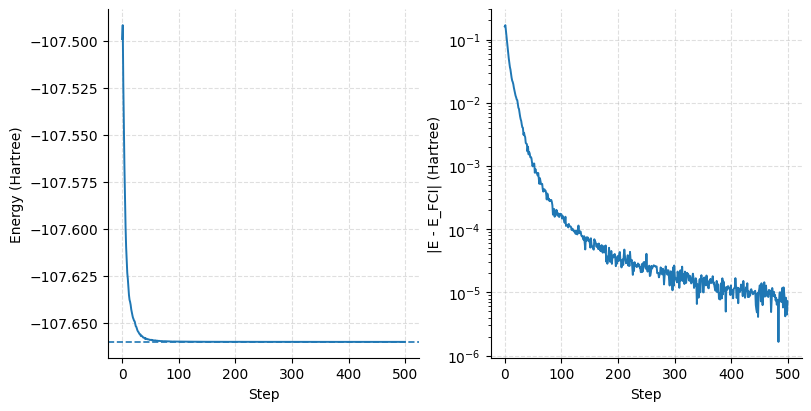

In [14]:
sampler = MCSampler(
    n_samples=1024,
    n_chains=1024,
    thermal_steps=0,
    alpha="adaptive",
    proposal="ham",
    blur=0.5,
    blur_kernel="ham",
)

state = MCState.init(
    model=model,
    hamiltonian=ham,
    sampler=sampler,
    n_alpha=n_alpha,
    n_beta=n_beta,
    init_method="hf",
    key=jax.random.key(0),
)

steps = 500
optimizer = optax.chain(
    adamsr(shift=1e-2, fallback=True),
    optax.scale(-5e-2)
)

vmc = VMC.init(state, optimizer)

history = []

for step in range(steps):
    stats = vmc.step()
    history.append(stats['energy'])

    if step % 10 == 0 or step == steps - 1:
        print(
            f"step={step:4d}  "
            f"energy={history[-1]: .8f}  "
            f"variance={stats['variance']: .8f}  "
            f"acc={stats['accept']:.3f}  "
            f"ess={stats['ess']: .1f}  "
            f"n_unique={stats['n_unique']: .0f}  "
            f"n_eval={stats['n_eval']: .0f}  "
            f"n_conn={stats['n_conn_eloc']: .0f}  "
            f"alpha={stats['alpha']: .3f}  "
        )

        time_items = sorted(
            (k[5:], float(stats[k])) for k in stats if k.startswith("time_")
        )
        if time_items:
            line = " | ".join(f"{name}= {val:.4f}" for name, val in time_items)
            print(f"         times: " + line)

# e_fci = -108.843255995666
plot_convergence(history, e_fci)
plt.show()